# ROV Log Exploratory Data Analysis (EDA)

This notebook analyzes the ROV telemetry dataset to understand:
- The types of events/telemetry recorded.
- Event counts and distributions.
- Sampling frequencies (Hz) for each telemetry type.

In [16]:
import json
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

log_path = '../../seaseer-dashboard/public/test_jsons/ROV-Log-2026-05-02-2026-05-05-0505205315.json'

with open(log_path, 'r') as f:
    raw_data = json.load(f)

print(f"Loaded {len(raw_data)} raw telemetry entries.")

Loaded 18204 raw telemetry entries.


## 1. Event Type Distribution

Let's see what types of events exist in the log and their respective frequency of occurrence.

Event Type Counts:
type
depth       6068
attitude    6068
sonar       6068
Name: count, dtype: int64


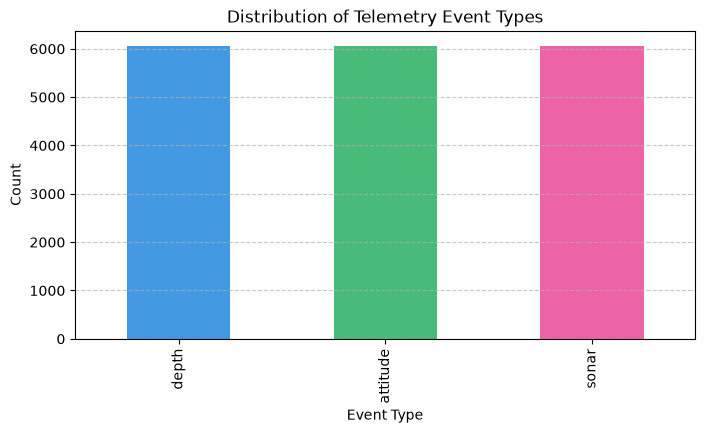

In [17]:
df_raw = pd.DataFrame(raw_data)

# Count of events by type
event_counts = df_raw['type'].value_counts()
print("Event Type Counts:")
print(event_counts)

# Plot the counts
plt.figure(figsize=(8, 4))
event_counts.plot(kind='bar', color=['#4299e1', '#48bb78', '#ed64a6'])
plt.title("Distribution of Telemetry Event Types")
plt.ylabel("Count")
plt.xlabel("Event Type")
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

## 2. Analyzing Sampling Frequency (Hz)

Let's calculate the sampling interval (difference in time between successive entries of the same type) to determine the recording rate in Hz.

In [18]:
for etype in df_raw['type'].unique():
    df_subset = df_raw[df_raw['type'] == etype].copy()
    
    # Calculate time differences in seconds
    # timestamps are in milliseconds
    df_subset = df_subset.sort_values('timestamp')
    time_diffs = df_subset['timestamp'].diff() / 1000.0
    
    mean_diff = time_diffs.mean()
    median_diff = time_diffs.median()
    hz = 1.0 / mean_diff if mean_diff > 0 else 0
    
    print(f"\n--- Event Type: {etype} ---")
    print(f"Mean interval: {mean_diff:.3f} seconds")
    print(f"Median interval: {median_diff:.3f} seconds")
    print(f"Approximate Frequency: {hz:.2f} Hz")


--- Event Type: depth ---
Mean interval: 0.699 seconds
Median interval: 0.529 seconds
Approximate Frequency: 1.43 Hz

--- Event Type: attitude ---
Mean interval: 0.699 seconds
Median interval: 0.529 seconds
Approximate Frequency: 1.43 Hz

--- Event Type: sonar ---
Mean interval: 0.699 seconds
Median interval: 0.529 seconds
Approximate Frequency: 1.43 Hz


## 3. Payloads Breakdown & Basic Stats

Let's unpack the nested payload structures into flat columns for each type.

In [19]:
# Depth & Temperature Statistics
df_depth = pd.json_normalize(df_raw[df_raw['type'] == 'depth'].to_dict(orient='records'))
print("\n--- Depth & Temp Statistics ---")
print(df_depth[['payload.depth', 'payload.temperature']].describe())

# Attitude (Yaw, Pitch, Roll) Statistics
df_att = pd.json_normalize(df_raw[df_raw['type'] == 'attitude'].to_dict(orient='records'))
print("\n--- Attitude (Yaw, Pitch, Roll) Statistics ---")
print(df_att[['payload.yaw', 'payload.roll', 'payload.pitch']].describe())

# Sonar Statistics
df_sonar = pd.json_normalize(df_raw[df_raw['type'] == 'sonar'].to_dict(orient='records'))
print("\n--- Sonar Statistics ---")
print(df_sonar[['payload.distance', 'payload.altitude']].describe())


--- Depth & Temp Statistics ---
       payload.depth  payload.temperature
count    6068.000000          6068.000000
mean        2.051900            19.017863
std         2.585047             2.997661
min         0.000000            16.280000
25%         0.160000            17.120000
50%         0.270000            17.800000
75%         5.310000            18.780000
max         8.250000            26.110000

--- Attitude (Yaw, Pitch, Roll) Statistics ---
       payload.yaw  payload.roll  payload.pitch
count  6068.000000   6068.000000    6068.000000
mean    238.547569      0.466197     -23.262495
std      96.455276      3.319755      31.078816
min       0.062866    -20.930786    -147.555080
25%     151.767567     -0.302673     -33.907875
50%     298.102950      0.007828     -14.976715
75%     317.726490      0.369453       0.024086
max     359.561250     16.389190      79.547000

--- Sonar Statistics ---
       payload.distance  payload.altitude
count       6068.000000       6068.000000

## 4. Time Series Visualizations

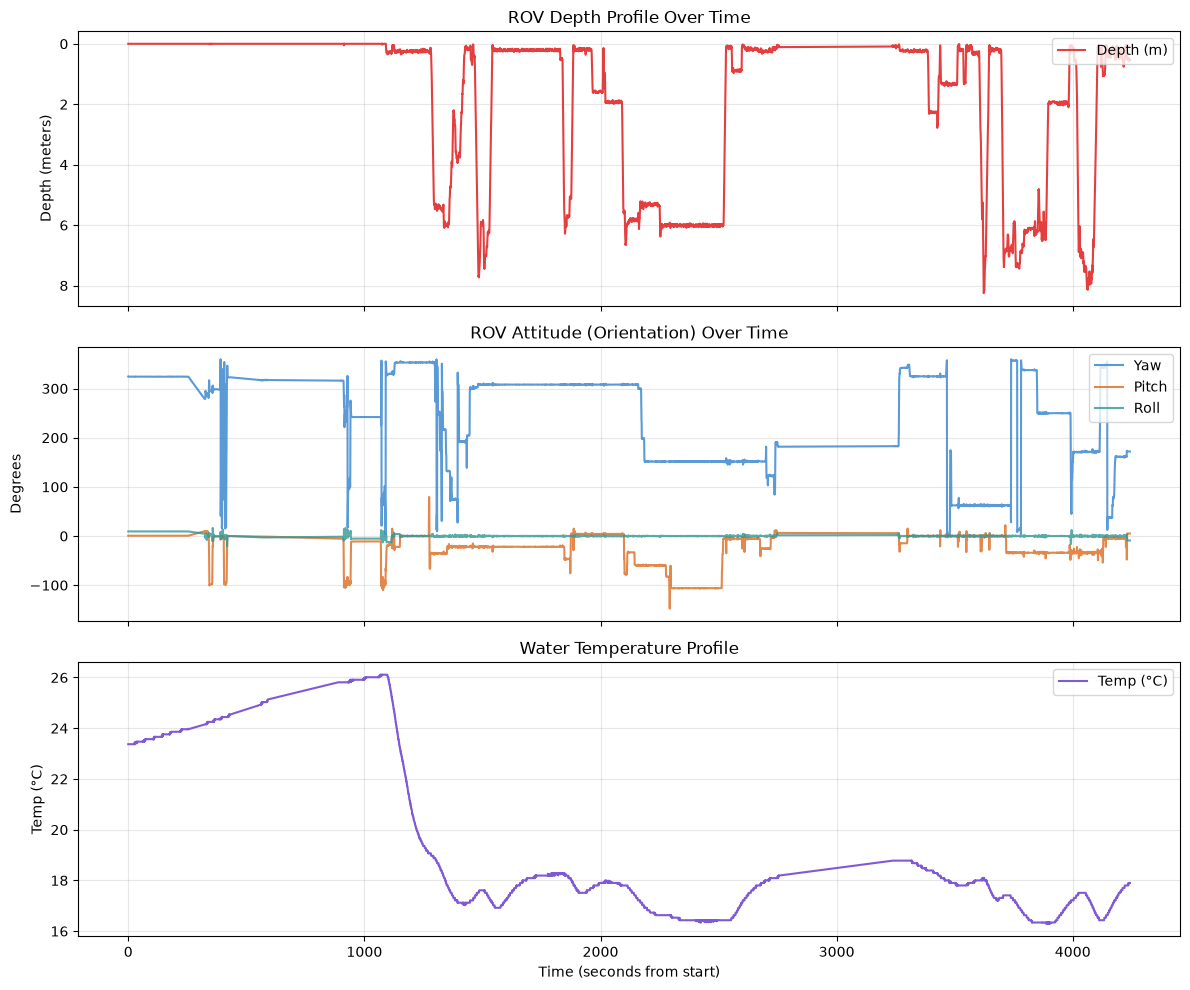

In [20]:
# Convert timestamp to relative seconds from start for cleaner plotting
start_ts = df_depth['timestamp'].min()
df_depth['relative_time'] = (df_depth['timestamp'] - start_ts) / 1000.0
df_att['relative_time'] = (df_att['timestamp'] - start_ts) / 1000.0

fig, axes = plt.subplots(3, 1, figsize=(12, 10), sharex=True)

# Depth Plot
axes[0].plot(df_depth['relative_time'], df_depth['payload.depth'], color='#e53e3e', label='Depth (m)')
axes[0].set_ylabel('Depth (meters)')
axes[0].invert_yaxis()  # Depth is typically plotted downwards
axes[0].legend(loc='upper right')
axes[0].set_title('ROV Depth Profile Over Time')
axes[0].grid(True, alpha=0.3)

# Attitude (Yaw, Pitch, Roll) Plot
axes[1].plot(df_att['relative_time'], df_att['payload.yaw'], color='#3182ce', label='Yaw', alpha=0.8)
axes[1].plot(df_att['relative_time'], df_att['payload.pitch'], color='#dd6b20', label='Pitch', alpha=0.8)
axes[1].plot(df_att['relative_time'], df_att['payload.roll'], color='#319795', label='Roll', alpha=0.8)
axes[1].set_ylabel('Degrees')
axes[1].legend(loc='upper right')
axes[1].set_title('ROV Attitude (Orientation) Over Time')
axes[1].grid(True, alpha=0.3)

# Temperature Plot
axes[2].plot(df_depth['relative_time'], df_depth['payload.temperature'], color='#805ad5', label='Temp (°C)')
axes[2].set_ylabel('Temp (°C)')
axes[2].set_xlabel('Time (seconds from start)')
axes[2].legend(loc='upper right')
axes[2].set_title('Water Temperature Profile')
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()